# EDA & Pre-Processing

In [223]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score

## 1. Load Data

In [224]:
costumer = pd.read_csv("customer_info.csv")
costumer

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33033,39996,Joshua Howard,male,05/16/1973 02:04 PM,0.0,0.0,2.0,1.0,475.0,13488.0,...,1154.0,62.0,1598.0,366.0,162.0,0.261352,2014.0,NaN,38.742306,-9.163971
33034,39997,Anthony Hines,male,05/10/1955 01:19 AM,1.0,0.0,1.0,1.0,8430.0,14408.0,...,602.0,220.0,2105.0,227.0,97.0,0.143479,2014.0,NaN,38.748505,-9.193445
33035,39998,Edna Hasselman,female,05/15/1945 11:09 PM,1.0,1.0,0.0,4.0,8029.0,1480.0,...,NaN,1719.0,89.0,258.0,206.0,0.181917,2012.0,NaN,38.776003,-9.137943
33036,39999,George Kramer,male,05/25/1951 09:02 PM,1.0,1.0,1.0,6.0,8364.0,3114.0,...,113.0,410.0,NaN,225.0,385.0,0.807259,2017.0,NaN,38.736034,-9.145235


In [225]:
costumer_basket = pd.read_csv("customer_basket.csv")
costumer_basket

,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807
...,...,...,...
99995,7685930,"['yams', 'airpods', 'shrimp']",21357
99996,2998960,"['cake', 'chocolate bread', 'cologne', 'beer',...",7817
99997,4409376,"['chicken', 'frozen smoothie', 'milk', 'body s...",35497
99998,3650163,"['metroid fusion', 'cat food', 'melons', 'ring...",13412


## 2. Initial Inspection — customer_info

In [226]:
costumer.info()

<class 'pandas.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   customer_name                            33038 non-null  str    
 2   customer_gender                          33038 non-null  str    
 3   customer_birthdate                       32873 non-null  str    
 4   kids_home                                32708 non-null  float64
 5   teens_home                               32708 non-null  float64
 6   number_complaints                        32377 non-null  float64
 7   distinct_stores_visited                  32708 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               32377 non-null  float64
 10  typical_hour                             32377 non-null  

In [227]:
costumer.isnull().sum()

customer_id                                    0
customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                    330
teens_home                                   330
number_complaints                            661
distinct_stores_visited                      330
lifetime_spend_groceries                       0
lifetime_spend_electronics                   661
typical_hour                                 661
lifetime_spend_vegetables                    661
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                330
lifetime_spend_meat                          661
lifetime_spend_fish                          991
lifetime_spend_hygiene                       330
lifetime_spend_videogames                    661
lifetime_spend_petfood                       661
lifetime_total_distinct_products               0
percentage_of_produc

In [228]:
costumer.duplicated().sum()

np.int64(0)

## 3. Initial Inspection — customer_basket

In [229]:
costumer_basket.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   invoice_id     100000 non-null  int64
 1   list_of_goods  100000 non-null  str  
 2   customer_id    100000 non-null  int64
dtypes: int64(2), str(1)
memory usage: 14.7 MB


In [230]:
costumer_basket.duplicated().sum()
# costumer_basket is okay, no nulls, no duplicates

np.int64(0)

## 4. Missing Values — MICE Imputation

In [231]:
missing_pct = costumer.isnull().sum() * 100 / len(costumer)
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

loyalty_card_number                        39.669472
lifetime_spend_fish                         2.999576
number_complaints                           2.000726
lifetime_spend_vegetables                   2.000726
lifetime_spend_meat                         2.000726
lifetime_spend_videogames                   2.000726
typical_hour                                2.000726
lifetime_spend_electronics                  2.000726
lifetime_spend_petfood                      2.000726
distinct_stores_visited                     0.998850
teens_home                                  0.998850
kids_home                                   0.998850
lifetime_spend_hygiene                      0.998850
lifetime_spend_alcohol_drinks               0.998850
percentage_of_products_bought_promotion     0.998850
customer_birthdate                          0.499425
dtype: float64


In [232]:
#The creation of two variables
current_year = datetime.now().year

# Convert birthdate to age
costumer['age'] = current_year - pd.to_datetime(costumer['customer_birthdate'], format='mixed').dt.year

# Binary flag for loyalty card
costumer['has_loyalty_card'] = costumer['loyalty_card_number'].notnull().astype(int)

# Columns excluded from MICE: non-numeric / identifiers / already-derived flags
cols_to_drop_for_mice = [
    'customer_id',
    'customer_name',
    'latitude',
    'longitude',
    'customer_birthdate',
    'loyalty_card_number'
]


# FIX: errors='ignore' avoids KeyError if any column was already dropped
cols_mice = costumer.drop(columns=cols_to_drop_for_mice, errors='ignore').select_dtypes(include='number').columns

imputer = IterativeImputer(max_iter=10, random_state=42)
costumer[cols_mice] = imputer.fit_transform(costumer[cols_mice])


print("Missing values after MICE:")
print(costumer.isnull().sum())

Missing values after MICE:
customer_id                                    0
customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                      0
teens_home                                     0
number_complaints                              0
distinct_stores_visited                        0
lifetime_spend_groceries                       0
lifetime_spend_electronics                     0
typical_hour                                   0
lifetime_spend_vegetables                      0
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                  0
lifetime_spend_meat                            0
lifetime_spend_fish                            0
lifetime_spend_hygiene                         0
lifetime_spend_videogames                      0
lifetime_spend_petfood                         0
lifetime_total_distinct_products          

`customer_birthdate` and `loyalty_card_number` will be removed later

## 5. Outlier Visualisation & Capping

Capping is applied only to **spend / behavioural** numeric columns —  
identifiers (`customer_id`), coordinates (`latitude`, `longitude`) and the  
binary/encoded columns are excluded.

In [233]:
# Columns that should NOT be capped
exclude_from_capping = [
    'customer_id', 'customer_gender', 'latitude', 'longitude', 'year_first_transaction','customer_birthdate']

cap_cols = [
    col for col in costumer.select_dtypes(include='number').columns
    if col not in exclude_from_capping
]

n_rows = math.ceil(len(cap_cols) / 3)

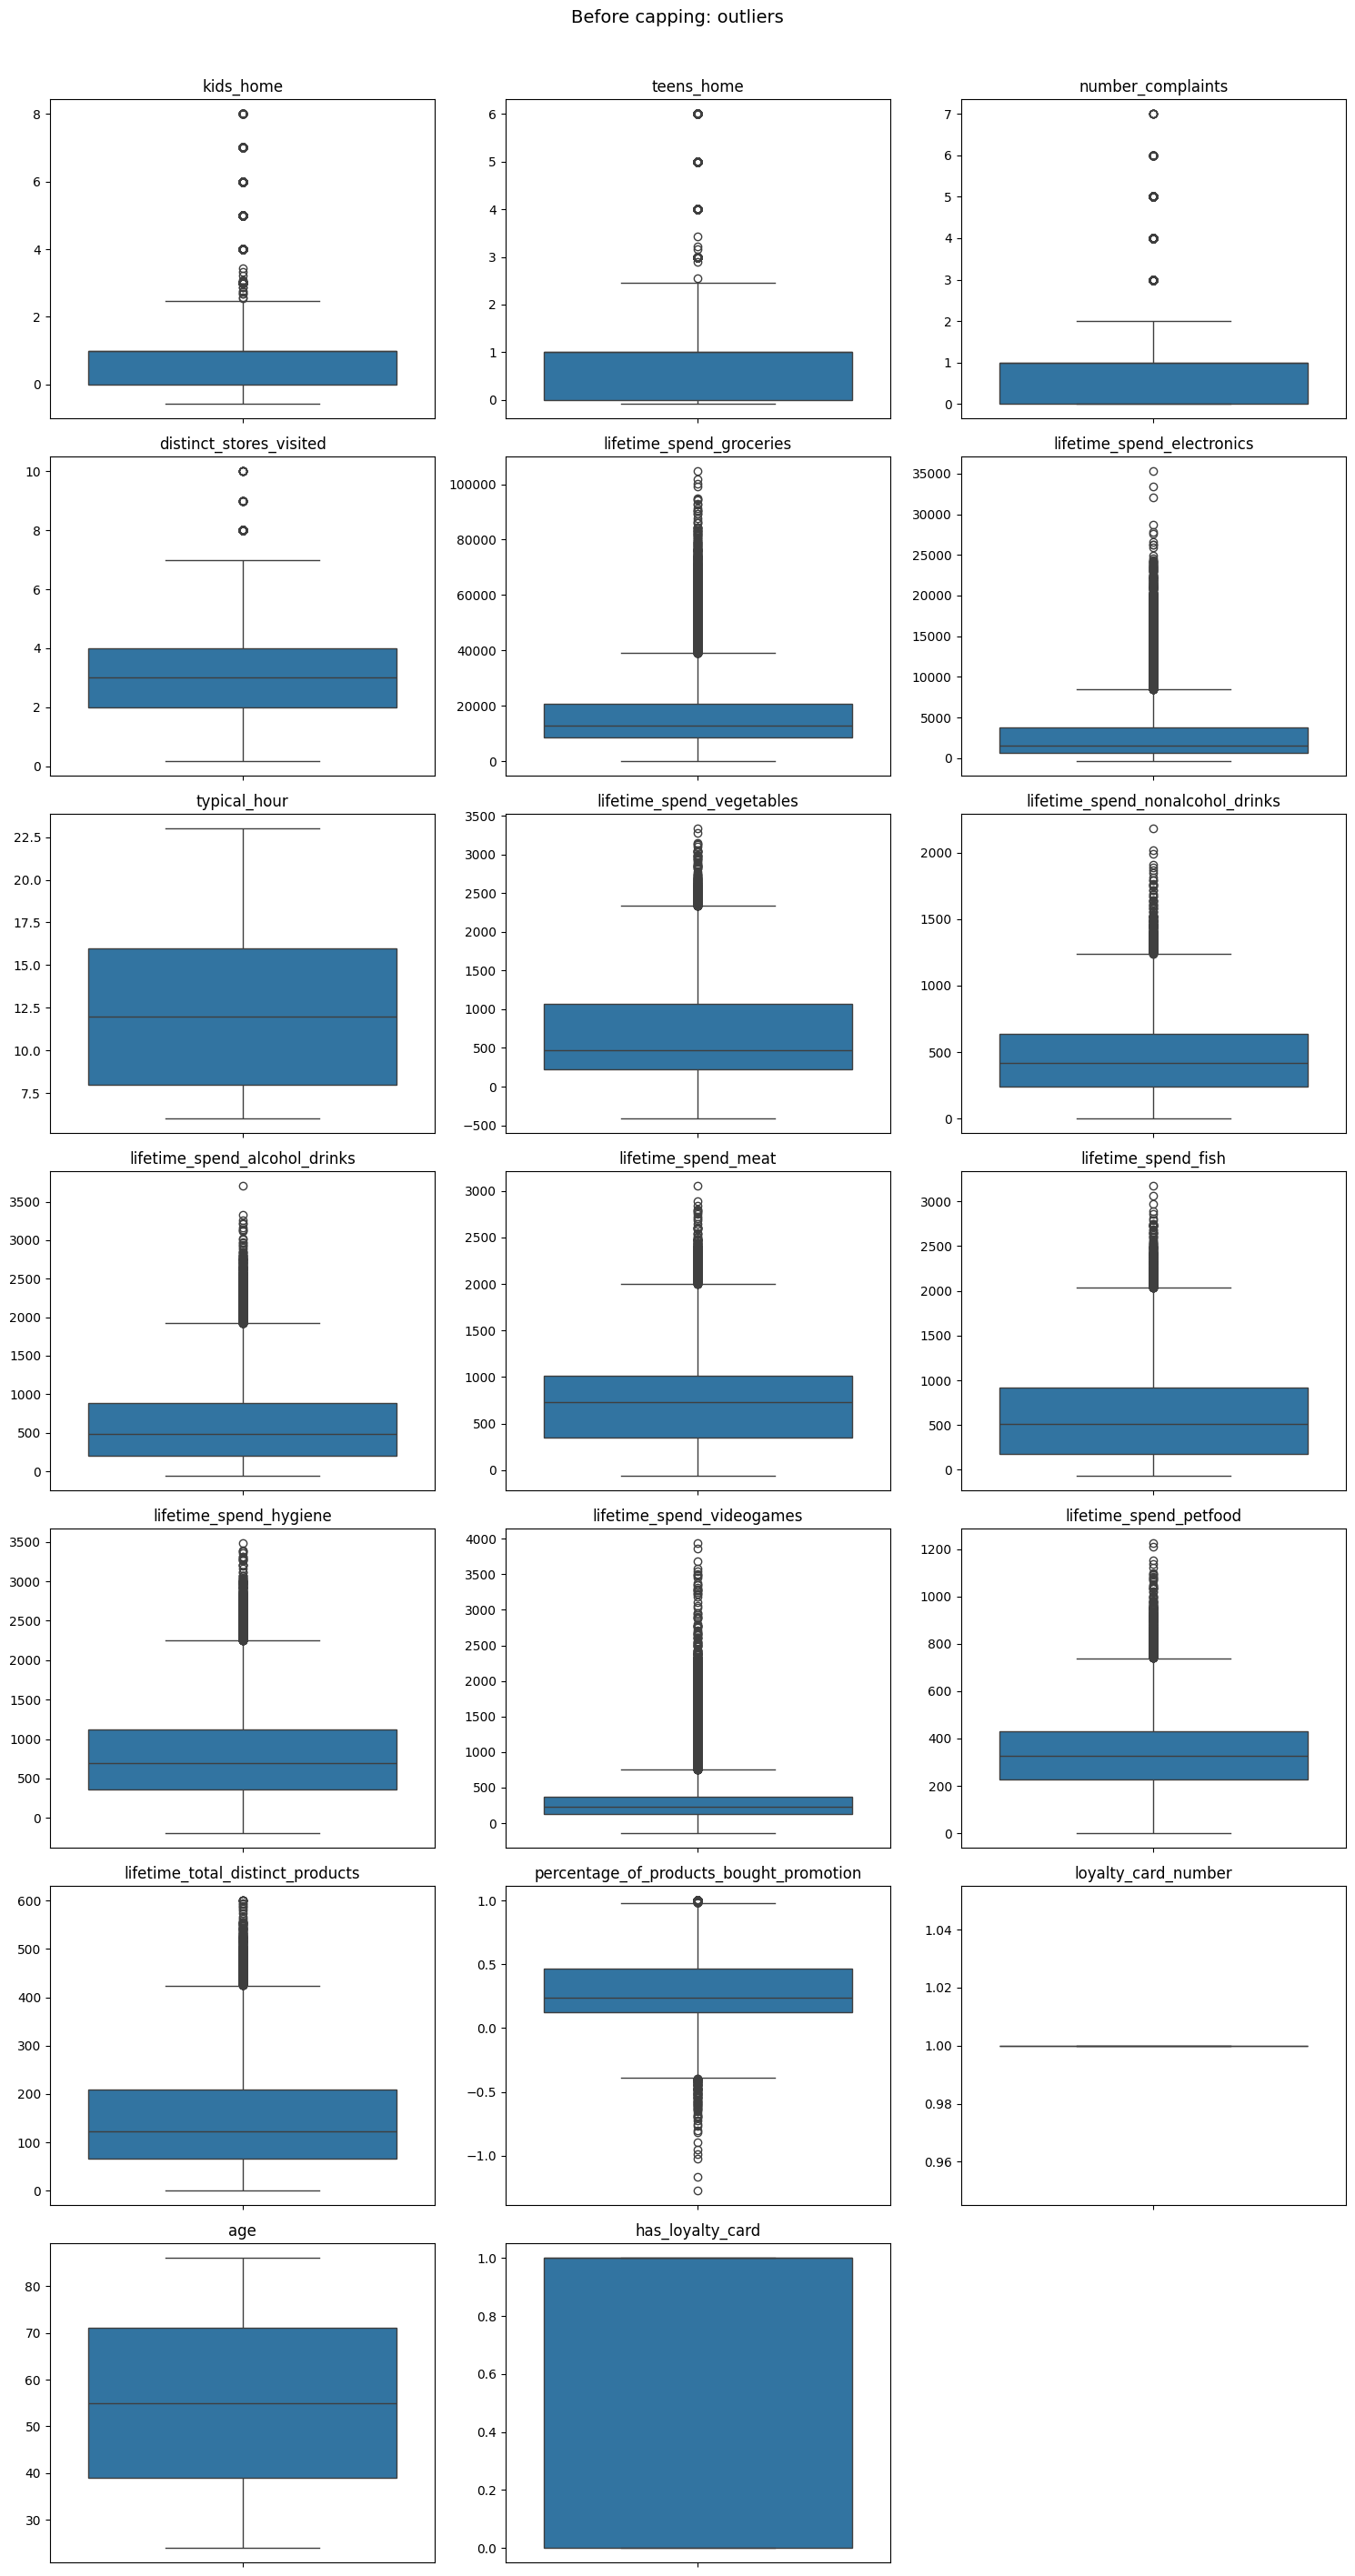

In [234]:
fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(cap_cols):
    sns.boxplot(y=costumer[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
# FIX: use fig.suptitle instead of plt.title for multi-subplot figures
fig.suptitle("Before capping: outliers", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [235]:
for col in cap_cols:
    Q1 = costumer[col].quantile(0.25)
    Q3 = costumer[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = max(0,Q1 - 1.5 * IQR)
    upper = Q3 + 1.5 * IQR
    costumer[col] = np.clip(costumer[col], lower, upper)

print("Outlier capping applied to:", cap_cols)

Outlier capping applied to: ['kids_home', 'teens_home', 'number_complaints', 'distinct_stores_visited', 'lifetime_spend_groceries', 'lifetime_spend_electronics', 'typical_hour', 'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene', 'lifetime_spend_videogames', 'lifetime_spend_petfood', 'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion', 'loyalty_card_number', 'age', 'has_loyalty_card']


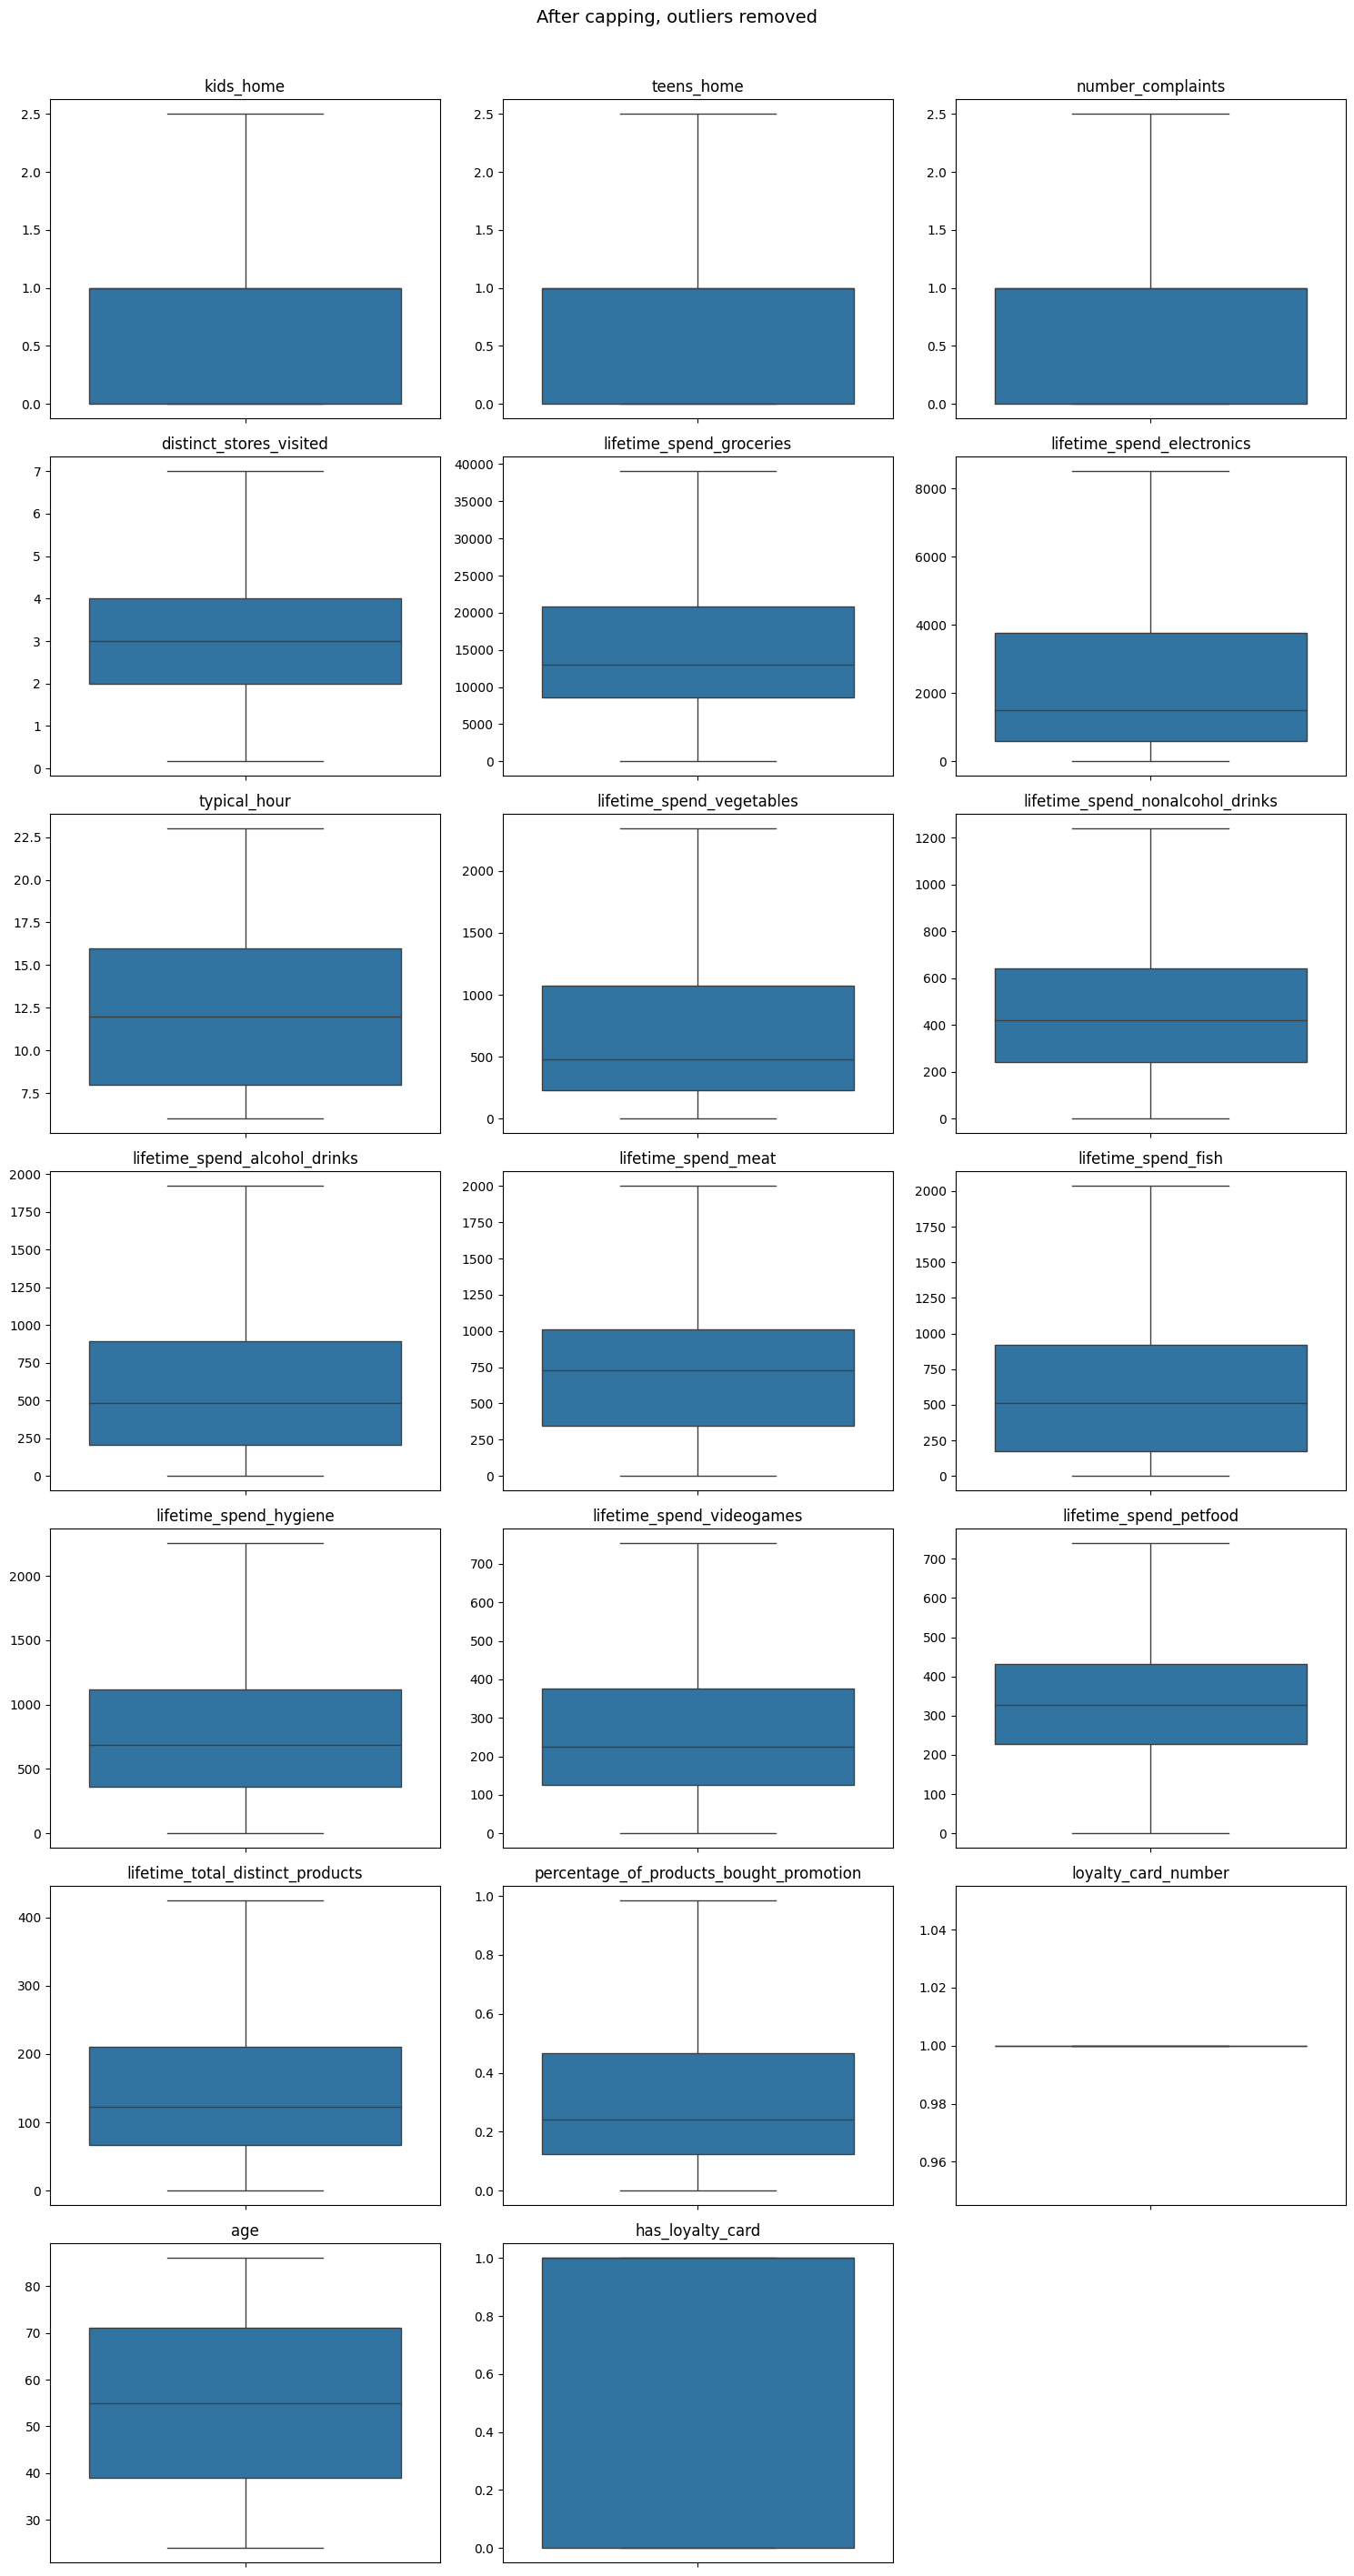

In [236]:
fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(cap_cols):
    sns.boxplot(y=costumer[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
# FIX: use fig.suptitle instead of plt.title
fig.suptitle("After capping, outliers removed", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Feature Engineering

In [237]:
# Convert first transaction year to seniority
costumer['years_as_customer'] = current_year - costumer['year_first_transaction']

# Encode gender — astype(str) guards against any unexpected NaN
le = LabelEncoder()
costumer['customer_gender'] = le.fit_transform(costumer['customer_gender'].astype(str))

# Combine 'kids_at_home' with 'teens_at_home'
costumer['dependents_home'] = costumer['kids_home'] + costumer['teens_home']

costumer_featured = costumer.copy()

# Create spend collumns
spend_cols = [col for col in costumer.columns if 'lifetime_spend_' in col]

# Log transform on spend columns to reduce skewness
costumer[spend_cols] = np.log1p(costumer[spend_cols])

# Drop non-predictive columns
cols_to_drop = ['customer_id', 'customer_name','customer_gender', 'customer_birthdate', 'latitude', 'longitude','year_first_transaction',
                'typical_hour', 'loyalty_card_number', 'kids_home', 'teens_home','has_loyalty_card','lifetime_total_distinct_products',
                ]

costumer = costumer.drop(columns=cols_to_drop, errors='ignore')


## 7. Scale & Export

In [238]:
costumer

,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,percentage_of_products_bought_promotion,age,years_as_customer,dependents_home
0,1.00000,3.0,9.370075,8.423761,5.924256,5.780744,5.181784,3.367296,5.365976,6.315358,5.549076,5.953243,0.631599,56.0,6.0,2.0
1,0.00000,2.0,9.524786,6.871091,7.607381,6.280396,4.564348,3.784190,2.772589,7.539559,5.811141,6.501290,0.149890,51.0,13.0,1.0
2,0.77717,2.0,9.426097,0.000000,6.320768,4.624973,4.779123,7.143618,5.613128,6.230481,4.624973,5.407172,0.069126,55.0,21.0,0.0
3,2.00000,1.0,8.921858,7.008505,4.442651,6.630683,7.033506,6.880384,6.988413,6.186209,6.625962,5.220356,0.253609,44.0,5.0,0.0
4,2.50000,1.0,9.125654,9.047866,5.942799,6.385194,6.577861,6.974479,6.923629,5.697093,6.625962,6.091310,0.186569,57.0,5.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33033,2.00000,1.0,6.165418,9.047866,5.252273,6.352629,6.902743,6.928538,7.051856,4.143135,6.625962,5.905362,0.261352,53.0,12.0,0.0
33034,1.00000,1.0,9.039671,9.047866,5.676754,6.210600,7.257003,7.188413,6.401917,5.398163,6.625962,5.429346,0.143479,71.0,12.0,1.0
33035,0.00000,4.0,8.990940,7.300473,7.378384,6.204558,4.770685,5.730100,5.517890,7.450080,4.499810,5.556828,0.181917,81.0,14.0,2.0
33036,1.00000,6.0,9.031812,8.043984,6.391917,5.717028,6.495266,6.694323,4.736198,6.018593,5.576265,5.420535,0.807259,75.0,9.0,2.0


In [239]:

# Scale
scaler = StandardScaler()
scaled_data = scaler.fit_transform(costumer)
costumer_preprocessed = pd.DataFrame(scaled_data, columns=costumer.columns)

print(f"Shape after merge & scaling: {costumer_preprocessed.shape}")
costumer_preprocessed.head()

Shape after merge & scaling: (33038, 16)


,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,percentage_of_products_bought_promotion,age,years_as_customer,dependents_home
0,0.147910,-0.097873,-0.045714,0.930635,-0.138874,-0.204798,-0.758622,-2.370421,-0.427514,-0.026578,0.260099,0.438647,1.135595,0.048670,-0.931644,0.152308
1,-1.172283,-0.704744,0.140983,-0.212980,1.307462,0.486014,-1.332383,-2.016998,-2.509760,1.168609,0.523850,1.268322,-0.647253,-0.228703,0.459419,-0.659549
2,-0.146268,-0.704744,0.021890,-5.273864,0.201856,-1.802749,-1.132800,0.830967,-0.229074,-0.109443,-0.669949,-0.388038,-0.946171,-0.006804,2.049206,-1.471405
3,1.468103,-1.311616,-0.586599,-0.111768,-1.412039,0.970316,0.962120,0.607810,0.875150,-0.152666,1.343913,-0.670854,-0.263380,-0.617027,-1.130368,-1.471405
4,2.128200,-1.311616,-0.340669,1.390318,-0.122939,0.630907,0.538704,0.687579,0.823134,-0.630189,1.343913,0.647663,-0.511503,0.104145,-1.130368,-1.471405


In [240]:
costumer_featured.to_csv("costumer_featured.csv", index=False)
costumer_preprocessed.to_csv("costumer_preprocessed.csv", index=False)
print("Saved → costumer_preprocessed.csv, costumer_featured.csv")

Saved → costumer_preprocessed.csv, costumer_featured.csv
